# Qwen3-VL-8B AVM Classification: Control vs Static Few-Shot vs Retrieval Few-Shot

Notebook for the  comparison:

- control: AVM prompt + target image
- static few-shot: same prompt + fixed 10 image-label examples + target image
- retrieval few-shot: same prompt + 10 visually similar retrieved image-label examples + target image

## 1. Install Dependencies

In [1]:
%pip install -q "git+https://github.com/huggingface/transformers" accelerate pillow datasets pandas tqdm matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Configuration

In [ ]:
from pathlib import Path
import os

os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")

MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
DATASET_ID = "Supermaxman/esa-hubble"
NUM_IMAGES = 266 #change this for smaller run

CACHE_MAX_IMAGE_EDGE = 1024
QUERY_MAX_IMAGE_EDGE = 768
FEWSHOT_MAX_IMAGE_EDGE = 512
MAX_NEW_TOKENS = 32

K_SHOT = 10
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
EXCLUDE_SAME_OBJECT = True

# Turn these on only when you want to generate missing predictions.
RUN_CONTROL = False
RUN_STATIC_FEWSHOT = False
RUN_RETRIEVAL_FEWSHOT = True

STATIC_FEWSHOT_INDICES = [1, 3, 4, 12, 15, 16, 50, 57, 74, 163]
EVAL_INDICES = [i for i in range(NUM_IMAGES) if i not in set(STATIC_FEWSHOT_INDICES)]

OUTPUT_DIR = Path("results_mac")
OUTPUT_DIR.mkdir(exist_ok=True)
STATIC_FEWSHOT_PATH
CONTROL_PATH = OUTPUT_DIR / "control_strict_codes_v1.txt"
 = OUTPUT_DIR / "fewshot_10_strict_codes_v1.txt"
RETRIEVAL_FEWSHOT_PATH = OUTPUT_DIR / "retrieval_10_strict_codes_v1.txt"

QUERY_PROMPT = "Return only the AVM code or codes for this image."

print("Eval rows:", len(EVAL_INDICES))
print("Control file:", CONTROL_PATH)
print("Static few-shot file:", STATIC_FEWSHOT_PATH)
print("Retrieval few-shot file:", RETRIEVAL_FEWSHOT_PATH)

Eval rows: 256
Control file: results_mac/control_strict_codes_v1.txt
Static few-shot file: results_mac/fewshot_10_strict_codes_v1.txt
Retrieval few-shot file: results_mac/retrieval_10_strict_codes_v1.txt


## 3. Load Model

In [3]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Loaded", MODEL_ID)
print("Model device:", model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Loaded Qwen/Qwen3-VL-8B-Instruct
Model device: cuda:0


## 4. Load Dataset and Reference Files

In [9]:
from itertools import islice
from urllib.request import urlopen
from PIL import Image
from datasets import load_dataset
from tqdm.auto import tqdm

Image.MAX_IMAGE_PIXELS = None

AVM_REFERENCE_URL = "https://raw.githubusercontent.com/QihanQG/ECS-189G-final-project/main/AVM_Reference"
TRUE_AVM_CODES_URL = "https://raw.githubusercontent.com/QihanQG/ECS-189G-final-project/main/TRUE_AVM_CODES"


def read_text_from_url(url):
    with urlopen(url) as response:
        return response.read().decode("utf-8")


def parse_true_avm_codes(text):
    labels_by_row = {}

    for line in text.splitlines():
        line = line.strip()
        if not line or ":" not in line:
            continue

        row_text, codes_text = line.split(":", 1)
        row_index = int(row_text.strip())
        labels_by_row[row_index] = [code.strip() for code in codes_text.split(",") if code.strip()]

    return [labels_by_row[i] for i in range(len(labels_by_row))]


def cache_image(image, max_edge=CACHE_MAX_IMAGE_EDGE):
    img = image.convert("RGB")
    img.thumbnail((max_edge, max_edge), Image.Resampling.LANCZOS)
    return img.copy()


avm_reference_text = read_text_from_url(AVM_REFERENCE_URL)
TRUE_AVM_CODES = parse_true_avm_codes(read_text_from_url(TRUE_AVM_CODES_URL))

rows = []
images = []
names = []

stream = load_dataset(DATASET_ID, split="train", streaming=True)
streamed_rows = islice(stream, NUM_IMAGES)

for row_index, row in enumerate(tqdm(streamed_rows, total=NUM_IMAGES, desc="Loading ESA/Hubble images")):
    images.append(cache_image(row["image"]))
    names.append((row.get("Name") or "").strip())
    rows.append({key: value for key, value in row.items() if key != "image"})

print("Loaded rows:", len(rows))
print("Cached images:", len(images))
print("Loaded true-code rows:", len(TRUE_AVM_CODES))


README.md:   0%|          | 0.00/14.8k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/200 [00:00<?, ?it/s]

Loading ESA/Hubble images:   0%|          | 0/266 [00:00<?, ?it/s]

Loaded rows: 266
Cached images: 266
Loaded true-code rows: 266


## 5. Prompt and Qwen Inference Helpers

In [16]:
import gc
import re

AVM_CODE_PATTERN = re.compile(r"\b[A-EX]\.\d+(?:\.\d+)*\b")

avm_task_instructions = """
You are an expert astronomical image classifier. Given an astronomical image, identify the type(s) of object(s) or phenomenon(a) depicted and express each as an AVM 1.1 code.

AVM 1.1 codes use this format: <Scale>.<Taxonomy>
Scale letters: A=Solar System, B=Milky Way, C=Local Universe, D=Early Universe, E=Unspecified.
Examples:
B.4.1.3 = Milky Way : Nebula : Type : Planetary
C.5.1.1 = Local Universe : Galaxy : Type : Spiral
D.5.5.3 = Early Universe : Galaxy : Grouping : Cluster

Return only the AVM code or codes. If there are multiple, separate them with commas.
No explanations, no labels, no extra text.
"""

avm_system_prompt = avm_reference_text + "\n\n" + avm_task_instructions


def clear_device_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()


def resize_image(image, max_edge):
    img = image.convert("RGB").copy()
    img.thumbnail((max_edge, max_edge), Image.Resampling.LANCZOS)
    return img


def extract_avm_codes(text):
    return AVM_CODE_PATTERN.findall(text)


def build_messages(query_image, examples=None):
    messages = [{"role": "system", "content": [{"type": "text", "text": avm_system_prompt}]}]

    for example in examples or []:
        messages.append({
            "role": "user",
            "content": [
                {"type": "image", "image": example["image"]},
                {"type": "text", "text": QUERY_PROMPT},
            ],
        })
        messages.append({
            "role": "assistant",
            "content": [{"type": "text", "text": ", ".join(example["codes"])}],
        })

    messages.append({
        "role": "user",
        "content": [
            {"type": "image", "image": query_image},
            {"type": "text", "text": QUERY_PROMPT},
        ],
    })
    return messages


def predict_codes(image, examples=None):
    query_image = resize_image(image, QUERY_MAX_IMAGE_EDGE)
    messages = build_messages(query_image, examples=examples)

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    try:
        with torch.inference_mode():
            out_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
        trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], out_ids)]
        reply = processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
        return extract_avm_codes(reply)
    finally:
        del inputs
        clear_device_memory()


static_fewshot_examples = [
    {
        "image": resize_image(images[index], FEWSHOT_MAX_IMAGE_EDGE),
        "codes": TRUE_AVM_CODES[index],
    }
    for index in STATIC_FEWSHOT_INDICES
]

print("Static few-shot examples:", len(static_fewshot_examples))

Static few-shot examples: 10


## 6. Retrieval Index

In [22]:
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

clip_model = None
clip_processor = None
IMAGE_EMBEDDINGS = None


def load_clip_model():
    global clip_model, clip_processor
    if clip_model is not None and clip_processor is not None:
        return

    device = "cuda" if torch.cuda.is_available() else "cpu"
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device).eval()
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    print("Loaded", CLIP_MODEL_ID, "on", device)


def get_clip_image_tensor(output):
    # Different CLIP/Transformers versions may return either a tensor or a model-output object.
    if torch.is_tensor(output):
        return output
    if hasattr(output, "image_embeds"):
        return output.image_embeds
    if hasattr(output, "pooler_output"):
        return output.pooler_output
    raise TypeError(f"Unexpected CLIP output type: {type(output)}")


@torch.no_grad()
def embed_images(pil_images, batch_size=16):
    load_clip_model()
    embeddings = []

    for start in tqdm(range(0, len(pil_images), batch_size), desc="Building retrieval index"):
        batch = pil_images[start:start + batch_size]
        inputs = clip_processor(images=batch, return_tensors="pt").to(clip_model.device)
        output = clip_model.get_image_features(**inputs)
        output = get_clip_image_tensor(output)
        output = F.normalize(output, dim=-1)
        embeddings.append(output.cpu())

    return torch.cat(embeddings, dim=0)


def build_retrieval_index():
    global IMAGE_EMBEDDINGS
    if IMAGE_EMBEDDINGS is None:
        IMAGE_EMBEDDINGS = embed_images(images)
    return IMAGE_EMBEDDINGS


def retrieve_neighbors(query_index, k=K_SHOT):
    embeddings = build_retrieval_index()
    similarities = embeddings @ embeddings[query_index]
    similarities = similarities.clone()
    similarities[query_index] = -1e9

    if EXCLUDE_SAME_OBJECT and names[query_index]:
        for index, name in enumerate(names):
            if name and name == names[query_index]:
                similarities[index] = -1e9

    return torch.topk(similarities, k).indices.tolist()


def retrieval_examples_for(query_index):
    neighbor_indices = retrieve_neighbors(query_index, k=K_SHOT)
    return [
        {
            "image": resize_image(images[index], FEWSHOT_MAX_IMAGE_EDGE),
            "codes": TRUE_AVM_CODES[index],
        }
        for index in neighbor_indices
    ]


print("Retrieval helpers ready. The CLIP index builds only when retrieval is run.")

Retrieval helpers ready. The CLIP index builds only when retrieval is run.


## 7. Batch Generation

In [23]:
def load_saved_predictions(path):
    predictions = {}
    if not Path(path).exists():
        return predictions

    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or ":" not in line:
            continue
        row_text, codes_text = line.split(":", 1)
        predictions[int(row_text.strip())] = codes_text.strip()

    return predictions


def save_predictions(predictions, path):
    lines = [f"{index}: {predictions[index]}" for index in sorted(predictions)]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


def run_batch(output_path, example_builder, label):
    predictions = load_saved_predictions(output_path)
    remaining = [index for index in EVAL_INDICES if index not in predictions]

    print(f"{label}: {len(predictions)} saved, {len(remaining)} remaining")

    for index in tqdm(remaining, desc=f"Running {label}"):
        examples = example_builder(index)
        codes = predict_codes(images[index], examples=examples)
        predictions[index] = ", ".join(codes)
        save_predictions(predictions, output_path)

    print(f"Saved {len(predictions)} rows to {output_path}")


if RUN_CONTROL:
    run_batch(CONTROL_PATH, lambda index: None, "control")
else:
    print("Skipped control generation")

if RUN_STATIC_FEWSHOT:
    run_batch(STATIC_FEWSHOT_PATH, lambda index: static_fewshot_examples, "static few-shot")
else:
    print("Skipped static few-shot generation")

if RUN_RETRIEVAL_FEWSHOT:
    run_batch(RETRIEVAL_FEWSHOT_PATH, retrieval_examples_for, "retrieval few-shot")
else:
    print("Skipped retrieval few-shot generation")


Skipped control generation
Skipped static few-shot generation
retrieval few-shot: 0 saved, 256 remaining


Running retrieval few-shot:   0%|          | 0/256 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded openai/clip-vit-base-patch32 on cuda


Building retrieval index:   0%|          | 0/17 [00:00<?, ?it/s]

Saved 256 rows to results_mac/retrieval_10_strict_codes_v1.txt


## 8. Metrics and Comparison

In [25]:
import pandas as pd


def parse_prediction_file(path):
    predictions = {}

    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or ":" not in line:
            continue
        row_text, codes_text = line.split(":", 1)
        predictions[int(row_text.strip())] = extract_avm_codes(codes_text)

    return predictions


def precision_recall_f1(predicted_codes, true_codes):
    predicted = set(predicted_codes)
    true = set(true_codes)

    if not predicted and not true:
        return 1.0, 1.0, 1.0
    if not predicted or not true:
        return 0.0, 0.0, 0.0

    correct = len(predicted & true)
    precision = correct / len(predicted)
    recall = correct / len(true)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return precision, recall, f1


def code_ancestors(code):
    parts = code.split(".")
    return [".".join(parts[:end]) for end in range(1, len(parts) + 1)]


def expand_with_ancestors(codes):
    expanded = set()
    for code in codes:
        expanded.update(code_ancestors(code))
    return expanded


def evaluate_predictions(predictions, indices):
    metric_rows = []

    for index in indices:
        true_codes = TRUE_AVM_CODES[index]
        predicted_codes = predictions.get(index, [])

        precision, recall, f1 = precision_recall_f1(predicted_codes, true_codes)
        h_precision, h_recall, h_f1 = precision_recall_f1(
            expand_with_ancestors(predicted_codes),
            expand_with_ancestors(true_codes),
        )

        metric_rows.append({
            "row_index": index,
            "predicted_codes": predicted_codes,
            "true_codes": true_codes,
            "exact": set(predicted_codes) == set(true_codes),
            "over_predicted": len(predicted_codes) > len(true_codes),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "h_precision": h_precision,
            "h_recall": h_recall,
            "h_f1": h_f1,
        })

    df = pd.DataFrame(metric_rows)
    summary = {
        "rows": len(df),
        "exact_matches": int(df["exact"].sum()),
        "exact_rate": float(df["exact"].mean()),
        "macro_precision": float(df["precision"].mean()),
        "macro_recall": float(df["recall"].mean()),
        "macro_f1": float(df["f1"].mean()),
        "over_predicted_rows": int(df["over_predicted"].sum()),
        "h_precision": float(df["h_precision"].mean()),
        "h_recall": float(df["h_recall"].mean()),
        "h_f1": float(df["h_f1"].mean()),
    }
    return summary, df


def print_summary(name, summary):
    print(f"\n{name}")
    print(f"Rows: {summary['rows']}")
    print(f"Exact set match: {summary['exact_matches']} / {summary['rows']} = {summary['exact_rate']:.4f}")
    print(f"Macro precision/recall/F1: {summary['macro_precision']:.4f} / {summary['macro_recall']:.4f} / {summary['macro_f1']:.4f}")
    print(f"Hierarchical precision/recall/F1: {summary['h_precision']:.4f} / {summary['h_recall']:.4f} / {summary['h_f1']:.4f}")
    print(f"Over-predicted rows: {summary['over_predicted_rows']}")


run_paths = {
    "control": CONTROL_PATH,
    "static_fewshot": STATIC_FEWSHOT_PATH,
    "retrieval_fewshot": RETRIEVAL_FEWSHOT_PATH,
}

predictions_by_run = {}
for run_name, path in run_paths.items():
    if Path(path).exists():
        predictions_by_run[run_name] = parse_prediction_file(path)
    else:
        print(f"Missing {run_name}: {path}")

indices_by_run = {
    run_name: sorted(set(predictions) & set(EVAL_INDICES))
    for run_name, predictions in predictions_by_run.items()
}

common_indices = sorted(set.intersection(*(set(indices) for indices in indices_by_run.values()))) if indices_by_run else []
print("Common rows across available runs:", len(common_indices))

summaries = []
per_run_dfs = {}

for run_name, predictions in predictions_by_run.items():
    summary_all, df_all = evaluate_predictions(predictions, indices_by_run[run_name])
    summary_common, df_common = evaluate_predictions(predictions, common_indices)

    print_summary(f"{run_name} - all completed rows", summary_all)
    print_summary(f"{run_name} - common rows only", summary_common)

    summaries.append({"run": run_name, "scope": "all_completed", **summary_all})
    summaries.append({"run": run_name, "scope": "common_rows", **summary_common})
    per_run_dfs[run_name] = df_common

comparison_df = pd.DataFrame(summaries)
comparison_df

Common rows across available runs: 256

control - all completed rows
Rows: 256
Exact set match: 19 / 256 = 0.0742
Macro precision/recall/F1: 0.1635 / 0.1445 / 0.1436
Hierarchical precision/recall/F1: 0.3031 / 0.3055 / 0.2947
Over-predicted rows: 69

control - common rows only
Rows: 256
Exact set match: 19 / 256 = 0.0742
Macro precision/recall/F1: 0.1635 / 0.1445 / 0.1436
Hierarchical precision/recall/F1: 0.3031 / 0.3055 / 0.2947
Over-predicted rows: 69

static_fewshot - all completed rows
Rows: 256
Exact set match: 30 / 256 = 0.1172
Macro precision/recall/F1: 0.1943 / 0.1992 / 0.1884
Hierarchical precision/recall/F1: 0.4475 / 0.4486 / 0.4390
Over-predicted rows: 40

static_fewshot - common rows only
Rows: 256
Exact set match: 30 / 256 = 0.1172
Macro precision/recall/F1: 0.1943 / 0.1992 / 0.1884
Hierarchical precision/recall/F1: 0.4475 / 0.4486 / 0.4390
Over-predicted rows: 40

retrieval_fewshot - all completed rows
Rows: 256
Exact set match: 50 / 256 = 0.1953
Macro precision/recall/F1:

,run,scope,rows,exact_matches,exact_rate,macro_precision,macro_recall,macro_f1,over_predicted_rows,h_precision,h_recall,h_f1
0,control,all_completed,256,19,0.074219,0.163542,0.144531,0.143620,69,0.303072,0.305545,0.294677
1,control,common_rows,256,19,0.074219,0.163542,0.144531,0.143620,69,0.303072,0.305545,0.294677
2,static_fewshot,all_completed,256,30,0.117188,0.194336,0.199219,0.188411,40,0.447466,0.448633,0.439003
3,static_fewshot,common_rows,256,30,0.117188,0.194336,0.199219,0.188411,40,0.447466,0.448633,0.439003
4,retrieval_fewshot,all_completed,256,50,0.195312,0.324219,0.304688,0.301432,40,0.524661,0.512663,0.506776
5,retrieval_fewshot,common_rows,256,50,0.195312,0.324219,0.304688,0.301432,40,0.524661,0.512663,0.506776


## 9. Graphs


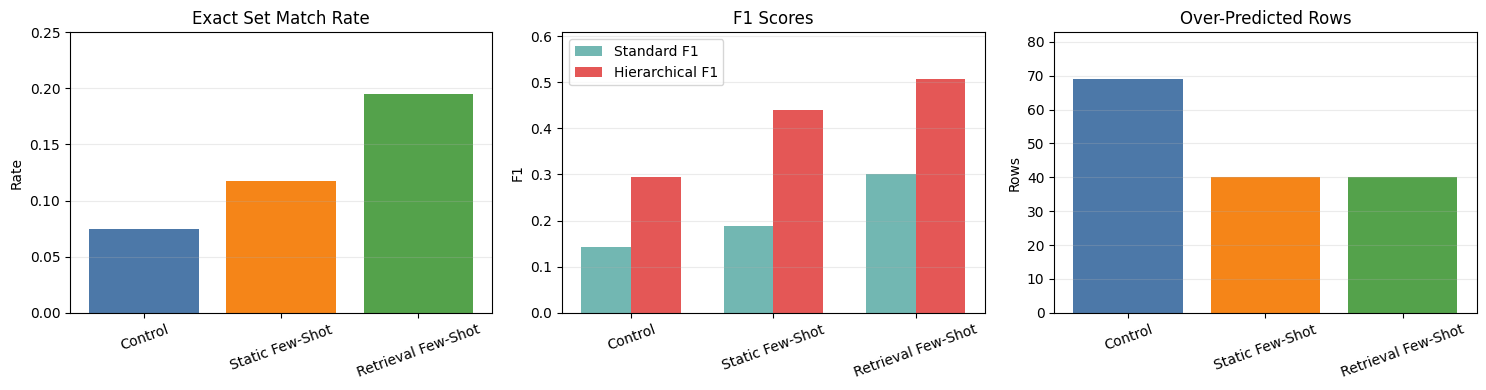

In [27]:
import matplotlib.pyplot as plt

#every run is compared on the exact same images.
metric_plot_df = comparison_df[comparison_df["scope"] == "common_rows"].copy()

run_labels = {
    "control": "Control",
    "static_fewshot": "Static Few-Shot",
    "retrieval_fewshot": "Retrieval Few-Shot",
}
metric_plot_df["run_label"] = metric_plot_df["run"].map(run_labels)

colors = ["#4C78A8", "#F58518", "#54A24B"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Exact set match rate.
axes[0].bar(metric_plot_df["run_label"], metric_plot_df["exact_rate"], color=colors)
axes[0].set_title("Exact Set Match Rate")
axes[0].set_ylabel("Rate")
axes[0].set_ylim(0, max(0.25, metric_plot_df["exact_rate"].max() * 1.2))
axes[0].tick_params(axis="x", rotation=20)

# Standard and hierarchical F1.
x = range(len(metric_plot_df))
bar_width = 0.35
axes[1].bar([value - bar_width / 2 for value in x], metric_plot_df["macro_f1"], width=bar_width, label="Standard F1", color="#72B7B2")
axes[1].bar([value + bar_width / 2 for value in x], metric_plot_df["h_f1"], width=bar_width, label="Hierarchical F1", color="#E45756")
axes[1].set_title("F1 Scores")
axes[1].set_ylabel("F1")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metric_plot_df["run_label"], rotation=20)
axes[1].set_ylim(0, max(0.6, metric_plot_df[["macro_f1", "h_f1"]].max().max() * 1.2))
axes[1].legend()

# Over-prediction count.
axes[2].bar(metric_plot_df["run_label"], metric_plot_df["over_predicted_rows"], color=colors)
axes[2].set_title("Over-Predicted Rows")
axes[2].set_ylabel("Rows")
axes[2].set_ylim(0, max(80, metric_plot_df["over_predicted_rows"].max() * 1.2))
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 10. Helped and Hurt Rows


In [26]:
if "control" in per_run_dfs:
    control_df = per_run_dfs["control"]

    for run_name in [name for name in per_run_dfs if name != "control"]:
        merged = control_df.merge(
            per_run_dfs[run_name],
            on="row_index",
            suffixes=("_control", f"_{run_name}"),
        )

        merged["run_better"] = merged[f"f1_{run_name}"] > merged["f1_control"]
        merged["run_worse"] = merged[f"f1_{run_name}"] < merged["f1_control"]

        print(f"\n{run_name} vs control")
        print("Better rows:", int(merged["run_better"].sum()))
        print("Worse rows:", int(merged["run_worse"].sum()))

        print("\nSample improvements")
        display(merged.loc[merged["run_better"], [
            "row_index", "true_codes_control", "predicted_codes_control", f"predicted_codes_{run_name}"
        ]].head(10))

        print("\nSample regressions")
        display(merged.loc[merged["run_worse"], [
            "row_index", "true_codes_control", "predicted_codes_control", f"predicted_codes_{run_name}"
        ]].head(10))
else:
    print("Control predictions are not available, so helped/hurt rows cannot be computed.")


static_fewshot vs control
Better rows: 38
Worse rows: 21

Sample improvements


,row_index,true_codes_control,predicted_codes_control,predicted_codes_static_fewshot
5,8,[C.5.1.7],[C.5.5.4],"[C.5.1.7, C.5.5.3]"
13,19,[B.4.1.4],[C.4.1.4],[B.4.1.4]
38,44,[B.3.6.4.2],[B.3.6.4.1],[B.3.6.4.2]
40,46,"[B.3.6.4.2, B.7.1.1]","[B.5.5.3, B.7.1.1, B.7.1.3]","[B.7.1.1, B.5.5.3]"
50,58,[B.3.6.4.2],[B.3.6.4.1],[B.3.6.4.2]
55,63,[B.4.1.2],[C.4.1.2],"[B.4.1.2, B.4.2.3.1]"
57,65,[B.4.2.1.1],[B.4.1.2],"[B.4.1.2, B.4.2.1.1]"
58,66,[B.4.1.2],[C.4.1.2],"[B.4.1.2, B.4.2.3.1]"
63,71,[C.5.1.1],[C.5.1.8],"[C.5.1.1, C.5.4.9]"
68,77,"[B.3.1.10, B.3.6.1]","[C.5.1.8, C.3.1.8, C.3.7.2.1, C.3.7.3.1]","[B.3.1.10, B.3.6.1]"



Sample regressions


,row_index,true_codes_control,predicted_codes_control,predicted_codes_static_fewshot
9,13,"[C.5.1.1, C.5.1.2]",[C.5.1.1],[C.5.1.6]
12,18,[B.4.1.4],"[B.4.1.4, C.6.1.2]",[B.4.1.5]
18,24,"[C.5.1.1, C.5.1.2]",[C.5.1.1],"[C.5.1.1, C.5.4.3]"
31,37,"[C.5.1.1, C.5.1.2]",[C.5.1.1],[B.4.1.4]
35,41,"[C.5.1.1, C.5.1.2]","[C.5.1.7, C.5.1.1]",[C.5.1.7]
49,56,[C.4.1.2],[C.4.1.2],[B.4.1.2]
62,70,[C.5.1.1],[C.5.1.1],"[C.5.1.1, C.5.4.9]"
107,116,[C.5.1.1],[C.5.1.1],[B.4.2.3.1]
109,118,[C.5.1.1],"[C.5.1.7, C.5.1.1]",[C.5.1.7]
130,139,[C.4.1.2],[C.4.1.2],"[B.4.1.2, B.4.2.1.1]"



retrieval_fewshot vs control
Better rows: 64
Worse rows: 18

Sample improvements


,row_index,true_codes_control,predicted_codes_control,predicted_codes_retrieval_fewshot
4,7,[B.3.6.4.2],[C.5.5.3],[B.3.6.4.2]
9,13,"[C.5.1.1, C.5.1.2]",[C.5.1.1],"[C.5.1.1, C.5.1.2]"
12,18,[B.4.1.4],"[B.4.1.4, C.6.1.2]",[B.4.1.4]
13,19,[B.4.1.4],[C.4.1.4],"[B.4.1.4, B.4.2.3.1]"
36,42,"[C.5.1.1, C.5.1.2]",[C.5.1.7],"[C.5.1.1, C.5.1.2]"
38,44,[B.3.6.4.2],[B.3.6.4.1],[B.3.6.4.2]
40,46,"[B.3.6.4.2, B.7.1.1]","[B.5.5.3, B.7.1.1, B.7.1.3]","[B.7.1.1, B.3.6.4.2]"
43,49,[B.4.1.3],[D.4.1.4],[B.4.1.3]
46,53,[D.5.5.3],"[C.5.5.4, C.5.5.3, C.5.5.2, C.5.5.1, C.5]",[D.5.5.3]
48,55,"[D.5.1.8, D.5.5.3]",[C.5.5.4],[D.5.5.3]



Sample regressions


,row_index,true_codes_control,predicted_codes_control,predicted_codes_retrieval_fewshot
19,25,"[C.5.1.1, C.5.1.2]",[C.5.1.1],[C.5.1.6]
20,26,"[C.5.1.1, C.5.1.2]",[C.5.1.1],[C.5.4.7]
31,37,"[C.5.1.1, C.5.1.2]",[C.5.1.1],[B.4.1.3]
32,38,"[C.5.1.1, C.5.1.2]",[C.5.1.1],"[C.5.1.1, C.5.4.7]"
35,41,"[C.5.1.1, C.5.1.2]","[C.5.1.7, C.5.1.1]",[C.5.1.7]
49,56,[C.4.1.2],[C.4.1.2],[B.4.1.2]
85,94,[B.4.1.2],[B.4.1.2],[C.4.1.2]
130,139,[C.4.1.2],[C.4.1.2],"[B.4.1.2, B.4.2.1.1]"
135,144,[C.4.2.1.1],"[C.4.1.4, C.4.2.1.1]",[C.4.1.4]
145,154,[C.5.1.1],"[C.5.1.1, C.5.5.1]",[C.5.1.7]


saved results\severity_by_run.png


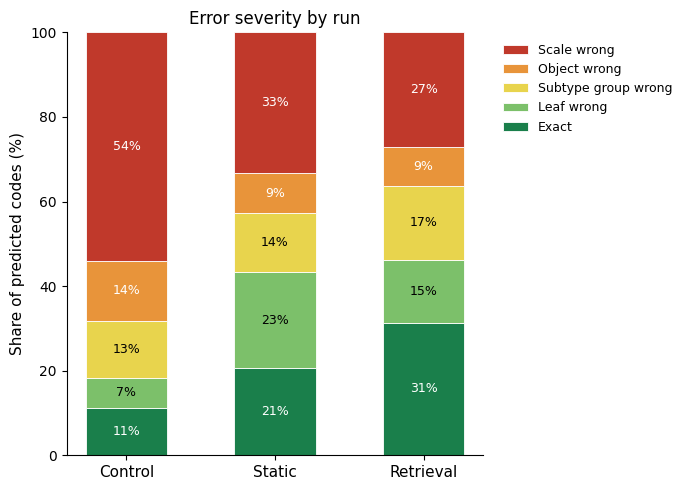

In [ ]:
# AVM error-severity analysis.
# Compares each run's predicted AVM codes against the true  AVM codes:
#   1. Invented rate: predicted codes that are not real AVM codes (true hallucination).
#   2. Severity ladder: for real-but-wrong codes, how deep they match the truth in the tree.


from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

REF_PATH = Path("AVM_Reference")          
TRUE_PATH = Path("TRUE_AVM_CODES")  
OUT_PATH = Path("results/severity_by_run.png")

RUNS = {
    "control":   Path("results/control_strict_codes_v1.txt"),
    "static":    Path("results/fewshot_10_strict_codes_v1.txt"),
    "retrieval": Path("results/retrieval_10_strict_codes_v1.txt"),
}

ns = {}
exec(open(REF_PATH).read(), ns)
SCALES = ns["AVM_SCALE"]
TAXONOMY = ns["AVM_TAXONOMY"]


def is_real_code(code):
    parts = code.split(".")
    scale = parts[0]
    tax = ".".join(parts[1:])
    if scale not in SCALES:
        return False
    if tax == "":
        return False
    return tax in TAXONOMY


def load_codes(path):
    rows = {}
    for line in open(path):
        line = line.strip()
        if not line or ":" not in line:
            continue
        idx, rest = line.split(":", 1)
        idx = int(idx.strip())
        codes = [c.strip() for c in rest.split(",") if c.strip()]
        rows[idx] = list(dict.fromkeys(codes))
    return rows


def prefix_match(a, b):
    n = 0
    for x, y in zip(a.split("."), b.split(".")):
        if x == y:
            n += 1
        else:
            break
    return n


def classify(pred, true_codes):
    if not is_real_code(pred):
        return "invented"
    if pred in true_codes:
        return "exact"
    best = max((prefix_match(pred, t) for t in true_codes), default=0)
    if best == 0:
        return "scale_wrong"
    if best == 1:
        return "object_wrong"
    if best == 2:
        return "subtype_wrong"
    return "leaf_wrong"


def shares(pred_rows, true_rows, common):
    order = ["invented", "scale_wrong", "object_wrong", "subtype_wrong", "leaf_wrong", "exact"]
    counts = {k: 0 for k in order}
    total = 0
    for idx in common:
        trues = true_rows.get(idx, [])
        if not trues:
            continue
        for p in pred_rows.get(idx, []):
            counts[classify(p, trues)] += 1
            total += 1
    return {k: counts[k] / total * 100 for k in order}


true_rows = load_codes(TRUE_PATH)
run_rows = {name: load_codes(p) for name, p in RUNS.items()}
common = sorted(set.intersection(*[set(r.keys()) for r in run_rows.values()]))
pct = {name: shares(run_rows[name], true_rows, common) for name in RUNS}

runs = ["control", "static", "retrieval"]
xlabels = ["Control", "Static", "Retrieval"]
buckets = ["exact", "leaf_wrong", "subtype_wrong", "object_wrong", "scale_wrong"]
names = {
    "exact": "Exact",
    "leaf_wrong": "Leaf wrong",
    "subtype_wrong": "Subtype group wrong",
    "object_wrong": "Object wrong",
    "scale_wrong": "Scale wrong",
}
colors = {
    "exact": "#1a7f4b",
    "leaf_wrong": "#7cc06a",
    "subtype_wrong": "#e8d44d",
    "object_wrong": "#e8943a",
    "scale_wrong": "#c0392b",
}

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(runs))
bottom = np.zeros(len(runs))
for b in buckets:
    vals = np.array([pct[r][b] for r in runs])
    ax.bar(x, vals, bottom=bottom, color=colors[b], label=names[b], width=0.55,
           edgecolor="white", linewidth=0.6)
    for i, v in enumerate(vals):
        if v >= 4:
            light = b in ("exact", "scale_wrong", "object_wrong")
            ax.text(x[i], bottom[i] + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white" if light else "black")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.set_ylabel("Share of predicted codes (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_title("Error severity by run", fontsize=12)
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_PATH, dpi=150, bbox_inches="tight")
print("saved", OUT_PATH)
